# Notebook 7 — Round Outcomes & Fire Power Prediction

**Dataset:** 741 battles, 51 bots, ~48M tick rows

**Questions:**
5. Can we predict opponent fire POWER (not just timing)?
6. What determines round outcomes?
10. Do the 3 game-state clusters hold at scale?
11. Are there "winning" game states?

**Key concepts:**
- **Fire power** ranges from 0.1 to 3.0. Higher power = more damage but slower bullet = easier to dodge.
  Smart bots adjust power based on distance (close → high power, far → low power) and energy.
- **Round outcome** = which bot has more energy / deals more damage. We have `scores.csv` per round.
- **Game state clusters** — the initial analysis found 3 clusters (close/mid/long range). With 50 bots,
  we may find more nuanced states.

In [1]:
import sys; sys.path.insert(0, '.')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
from _loader import (build_robot_index, load_stratified, attach_opponent_bot,
                     numeric_feature_cols, drop_redundant_features,
                     FIRE_POWER_LEAKAGE_COLS, CSV_ROOT_DEFAULT)

sns.set_theme(style='whitegrid', palette='muted')
CSV_ROOT = CSV_ROOT_DEFAULT

# scores.csv files are tiny (~2 KB each) — load EVERY one for round-outcome
# analysis (no stratified sampling needed).
all_scores_files = sorted(CSV_ROOT.rglob('scores.csv'))
print(f'Scores files: {len(all_scores_files)}')

# For ticks/waves we still need stratified sampling.
selection = build_robot_index(max_robots=50, battles_per_robot=3, seed=42)


Scores files: 3888


Indexed 3888 ticks.csv files across 50 distinct robots from 1 root(s).
Selected 50 robots × ~3 battles = 150 (battle, robot) pairs to load.


## 1. Load Scores Data

scores.csv is small — one row per round per perspective. We can load ALL of them.

In [2]:
# Load every scores.csv. The current schema has:
#   battle_id, round, ticks_in_round,
#   damage_dealt, damage_received, net_damage,
#   our_hit_rate, opponent_hit_rate, win_rate,
#   opponent_*_hash, battlefield_*, gun_cooling_rate, num_rounds_total
# `bot` (= observer) and `opponent` are added here from the directory tree.
score_frames = []
for f in all_scores_files:
    bot_name = f.parent.name
    battle_dir = f.parent.parent
    perspectives = [d.name for d in battle_dir.iterdir() if d.is_dir()]
    opponent_name = [p for p in perspectives if p != bot_name]
    if not opponent_name:
        continue
    try:
        df = pd.read_csv(f)
        df['bot'] = bot_name
        df['opponent'] = opponent_name[0]
        score_frames.append(df)
    except Exception:
        pass

scores = pd.concat(score_frames, ignore_index=True)
print(f'Total score rows: {len(scores):,}')
print(f'Unique bots: {scores["bot"].nunique()}')
print(f'Columns: {list(scores.columns)}')
scores.head()


Total score rows: 136,032
Unique bots: 50
Columns: ['battle_id', 'round', 'ticks_in_round', 'damage_dealt', 'damage_received', 'net_damage', 'our_hit_rate', 'opponent_hit_rate', 'win_rate', 'opponent_name_hash', 'opponent_bot_id_hash', 'opponent_version_hash', 'battlefield_width', 'battlefield_height', 'gun_cooling_rate', 'num_rounds_total', 'bot', 'opponent']


,battle_id,round,ticks_in_round,damage_dealt,damage_received,net_damage,our_hit_rate,opponent_hit_rate,win_rate,opponent_name_hash,opponent_bot_id_hash,opponent_version_hash,battlefield_width,battlefield_height,gun_cooling_rate,num_rounds_total,bot,opponent
0,000debb9,0,772,67.2,23.60,43.60,0.1905,0.1463,1.0000,-89311343,-1728310464,-1722226118,800,600,0.1,35,Midboss 1q.fast,WhiteFang 2.8.1
1,000debb9,1,750,19.5,39.15,-19.65,0.0976,0.1026,0.5000,-89311343,-1728310464,-1722226118,800,600,0.1,35,Midboss 1q.fast,WhiteFang 2.8.1
2,000debb9,2,866,40.1,23.33,16.77,0.1042,0.0625,0.6667,-89311343,-1728310464,-1722226118,800,600,0.1,35,Midboss 1q.fast,WhiteFang 2.8.1
3,000debb9,3,801,54.7,33.12,21.58,0.1591,0.1364,0.7500,-89311343,-1728310464,-1722226118,800,600,0.1,35,Midboss 1q.fast,WhiteFang 2.8.1
4,000debb9,4,633,35.5,57.50,-22.00,0.1212,0.1935,0.6000,-89311343,-1728310464,-1722226118,800,600,0.1,35,Midboss 1q.fast,WhiteFang 2.8.1


In [3]:
# Compute round winners. The current schema doesn't carry `total_score`; we use
# `net_damage` instead (damage_dealt - damage_received). The two perspectives
# of the same battle/round always sum to ~0 (one's gain is the other's loss),
# so the perspective with positive net_damage is the round winner.
paired = scores.groupby(['battle_id', 'round']).apply(
    lambda g: pd.Series({
        'bot_a': g.iloc[0]['bot'] if len(g) >= 2 else np.nan,
        'bot_b': g.iloc[1]['bot'] if len(g) >= 2 else np.nan,
        'net_a': g.iloc[0]['net_damage'] if len(g) >= 2 else np.nan,
        'net_b': g.iloc[1]['net_damage'] if len(g) >= 2 else np.nan,
        'win_a': g.iloc[0]['win_rate'] if len(g) >= 2 else np.nan,
    })
).dropna().reset_index()

# Prefer `win_rate` directly (it's already the win/loss/tie fraction the
# pipeline computed). Fall back to net_damage sign if win_rate is missing.
paired['winner'] = np.where(paired['win_a'] >= 0.5, paired['bot_a'], paired['bot_b'])
paired['margin'] = (paired['net_a'] - paired['net_b']).abs()

print(f'Paired rounds: {len(paired):,}')
print(f'\nTop winners:')
print(paired['winner'].value_counts().head(10))


Paired rounds: 68,016

Top winners:
winner
BeepBoop 2.0                   2646
Knight 0.6.28                  2536
ScalarR 0.005h.053-noshield    2494
Firestarter 2.0f               2477
Diamond 1.8.22                 2424
DrussGT 3.1.7                  2362
Tomcat 3.68                    2277
Combat 3.25.0                  2010
Roborio 1.2.4                  1933
Dookious 1.573c                1824
Name: count, dtype: int64


In [4]:
# Win rate matrix: for each ordered (bot_a, bot_b) pair, what fraction does A win?
win_rates = []
for (a, b), group in paired.groupby(['bot_a', 'bot_b']):
    wins_a = (group['winner'] == a).sum()
    total = len(group)
    win_rates.append({'bot_a': a, 'bot_b': b,
                      'win_rate_a': wins_a / total, 'n_rounds': total})

wr_df = pd.DataFrame(win_rates)

# Overall win rate per bot — pool wins from both bot_a and bot_b sides.
overall = []
for bot in scores['bot'].unique():
    as_a = wr_df[wr_df['bot_a'] == bot]
    as_b = wr_df[wr_df['bot_b'] == bot]
    total_wins = (as_a['win_rate_a'] * as_a['n_rounds']).sum() + \
                 ((1 - as_b['win_rate_a']) * as_b['n_rounds']).sum()
    total_rounds = as_a['n_rounds'].sum() + as_b['n_rounds'].sum()
    if total_rounds > 0:
        overall.append({'bot': bot,
                        'win_rate': total_wins / total_rounds,
                        'rounds': int(total_rounds)})

overall_df = pd.DataFrame(overall).sort_values('win_rate', ascending=False)
print('Overall win rates (top 15):')
print(overall_df.head(15).to_string(index=False))


Overall win rates (top 15):
                        bot  win_rate  rounds
               BeepBoop 2.0  0.994737    2660
ScalarR 0.005h.053-noshield  0.976125    2555
              Knight 0.6.28  0.941002    2695
              DrussGT 3.1.7  0.911969    2590
           Firestarter 2.0f  0.895841    2765
             Diamond 1.8.22  0.887912    2730
                Tomcat 3.68  0.783821    2905
              Combat 3.25.0  0.755639    2660
              Roborio 1.2.4  0.726692    2660
         GresSuffurd 0.4.13  0.713043    2415
           Neuromancer 7.12  0.684540    2555
           Gilgalad 1.99.5c  0.680644    2671
               Raven 3.56j8  0.677714    2625
            Dookious 1.573c  0.659675    2765
                  Pris 0.92  0.631393    2835


## 2. Fire Power Prediction (Question 5)

When the opponent fires, what power do they choose? The initial intuition showed we can detect
WHEN they fire (gun heat). Now: can we predict the POWER they'll use?

This matters for wave surfing — the bullet power determines bullet speed, which determines
the wave's travel time and the maximum escape angle.

In [5]:
# Load sampled ticks via the shared loader.
ticks = load_stratified('ticks.csv', selection, row_frac=0.20)
ticks = ticks[ticks['scan_available'] == 1].copy()
ticks = attach_opponent_bot(ticks, selection, csv_root=CSV_ROOT)
ticks = ticks.dropna(subset=['opponent_bot']).reset_index(drop=True)
ticks['observer_bot'] = ticks['robot_name']
print(f'Loaded {len(ticks):,} scan ticks ({ticks.memory_usage(deep=True).sum()/1e6:.0f} MB)')

# Filter to firing ticks only.
fire_ticks = ticks[ticks['opponent_fired'] == 1].copy()
print(f'Total fire events: {len(fire_ticks):,}')
print(f'Bots that fired: {fire_ticks["opponent_bot"].nunique()}')
print(f'\nFire power distribution:')
print(fire_ticks['opponent_fire_power'].describe())


Loaded 150 ticks.csv files → 1,003,073 rows × 65 cols, 50 robots (~354.6 MB)


Loaded 821,691 scan ticks (421 MB)
Total fire events: 55,291
Bots that fired: 46

Fire power distribution:
count    55291.000000
mean         1.318937
std          0.780398
min          0.100000
25%          0.434000
50%          1.881000
75%          1.950000
max          3.000000
Name: opponent_fire_power, dtype: float64


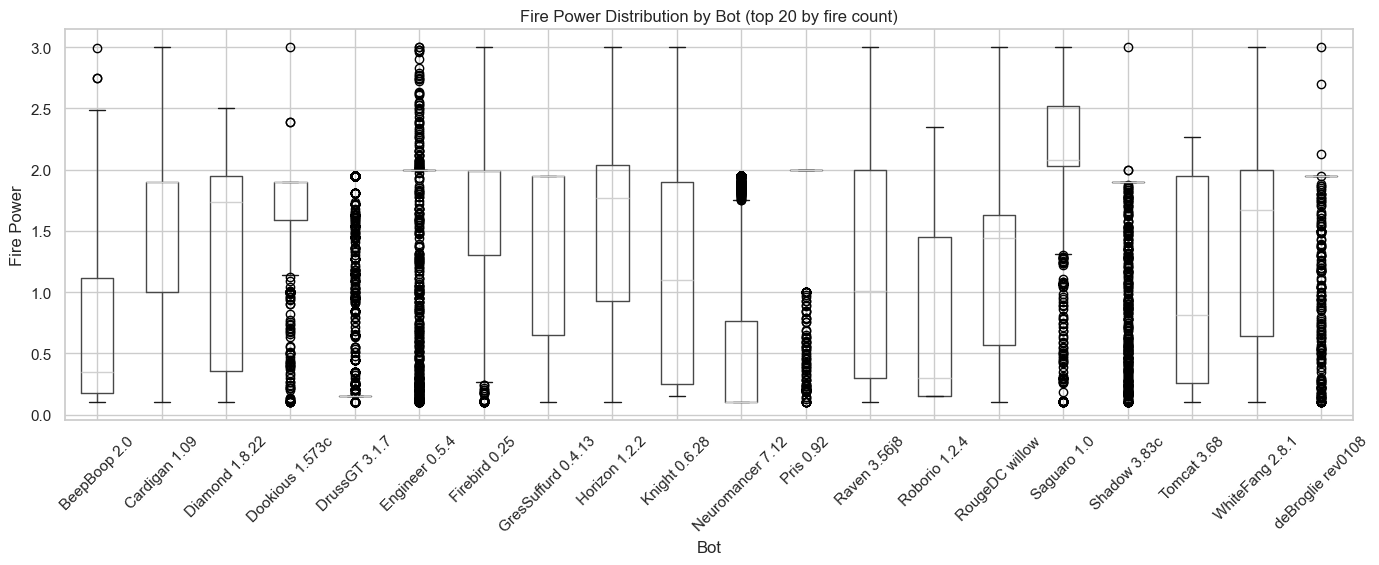

In [6]:
# Fire power distribution per bot
fig, ax = plt.subplots(figsize=(14, 6))
top_firers = fire_ticks['opponent_bot'].value_counts().head(20).index
fire_subset = fire_ticks[fire_ticks['opponent_bot'].isin(top_firers)]
fire_subset.boxplot(column='opponent_fire_power', by='opponent_bot', ax=ax, rot=45)
ax.set_title('Fire Power Distribution by Bot (top 20 by fire count)')
ax.set_xlabel('Bot')
ax.set_ylabel('Fire Power')
plt.suptitle('')
plt.tight_layout()
plt.show()

In [ ]:
# Honest fire-power prediction: predict opponent_fire_power on rows where the
# fire event was just detected, using ONLY pre-fire game state.
#
# Critical: drop the algebraic-identity columns. On the same fire-detection
# tick, the pipeline records:
#   opponent_bullet_speed   = 20 - 3 * opponent_fire_power
#   mea_for_opponent_bullet = asin(8 / opponent_bullet_speed)
# Including either gives R² = 1.000 trivially — see
# archive/2026-05-02-intuition-4.md §2.\n
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

leakage = set(FIRE_POWER_LEAKAGE_COLS)
feature_cols = numeric_feature_cols(fire_ticks, extra_exclude=leakage)
feature_cols = drop_redundant_features(feature_cols)
print(f'Predictors ({len(feature_cols)}, leakage cols excluded: {sorted(leakage)})')

X = fire_ticks[feature_cols].fillna(0).values
y = fire_ticks['opponent_fire_power'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Baseline: predict mean fire power.
mean_power = y_train.mean()
baseline_mae = mean_absolute_error(y_test, np.full_like(y_test, mean_power))

# Random Forest on honest predictors.
rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print(f'\nFire Power Prediction ({len(y_test):,} test samples):')
print(f'  Mean baseline: MAE={baseline_mae:.3f}')
print(f'  Random Forest: MAE={rf_mae:.3f}, R²={rf_r2:.3f}')
print(f'  Improvement:   {(1 - rf_mae/baseline_mae)*100:+.1f}% lower MAE')

# Feature importance.
importances = pd.Series(rf.feature_importances_, index=feature_cols)
top10 = importances.nlargest(10)
print(f'\nTop 10 honest features for fire power prediction:')
for feat, imp in top10.items():
    print(f'  {feat}: {imp:.4f}')


Predictors (46, leakage cols excluded: ['escape_angle_coverage', 'gf_current_at_power_1', 'gf_current_at_power_1_5', 'gf_current_at_power_2', 'mea_for_opponent_bullet', 'opponent_bullet_speed', 'opponent_fire_power', 'opponent_inferred_gun_heat', 'opponent_wave_distance', 'opponent_wave_eta', 'opponent_wave_remaining', 'ticks_since_opponent_fired'])



Fire Power Prediction (11,059 test samples):
  Mean baseline: MAE=0.712
  Random Forest: MAE=0.206, R²=0.809
  Improvement:   +71.0% lower MAE

Top 10 honest features for fire power prediction:
  mea_for_our_bullet: 0.3205
  our_bullet_speed: 0.2593
  opponent_energy: 0.1558
  energy_ratio: 0.0625
  scan_arc_width: 0.0312
  opponent_time_since_direction_change: 0.0203
  opponent_time_since_velocity_change: 0.0174
  distance: 0.0159
  opponent_dist_to_wall_min: 0.0102
  opponent_center_distance: 0.0097


## 3. Game State Clusters at Scale (Question 10)

The initial 5-bot analysis found 3 game state clusters. With 51 bots,
do we see more fine-grained states?

K=2: inertia=768930, silhouette=0.131


K=3: inertia=696448, silhouette=0.129


K=4: inertia=653077, silhouette=0.112


K=5: inertia=622098, silhouette=0.100


K=6: inertia=594153, silhouette=0.111


K=7: inertia=568609, silhouette=0.110


K=8: inertia=547760, silhouette=0.112


K=9: inertia=528413, silhouette=0.127


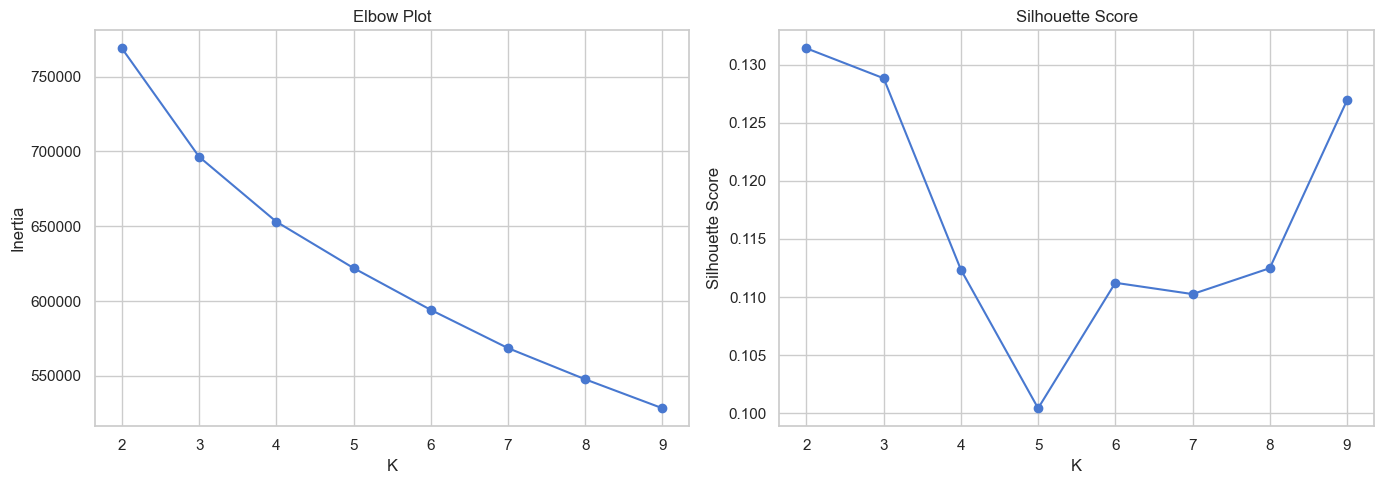

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Use a sample of scan ticks for clustering
cluster_cols = [
    'distance', 'opponent_velocity', 'opponent_lateral_velocity',
    'opponent_heading_delta', 'opponent_dist_to_wall_min',
    'our_lateral_velocity', 'our_dist_to_wall_min',
    'energy_ratio', 'distance_norm'
]

sample = ticks[cluster_cols].dropna().sample(n=min(100000, len(ticks)), random_state=42)
X_clust = StandardScaler().fit_transform(sample.values)

# Elbow + silhouette
ks = range(2, 10)
inertias = []
sil_scores = []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_clust)
    inertias.append(km.inertia_)
    s = silhouette_score(X_clust, labels, sample_size=10000)
    sil_scores.append(s)
    print(f'K={k}: inertia={km.inertia_:.0f}, silhouette={s:.3f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(list(ks), inertias, 'o-')
ax1.set_xlabel('K'); ax1.set_ylabel('Inertia'); ax1.set_title('Elbow Plot')
ax2.plot(list(ks), sil_scores, 'o-')
ax2.set_xlabel('K'); ax2.set_ylabel('Silhouette Score'); ax2.set_title('Silhouette Score')
plt.tight_layout()
plt.show()

Best K by silhouette: 2


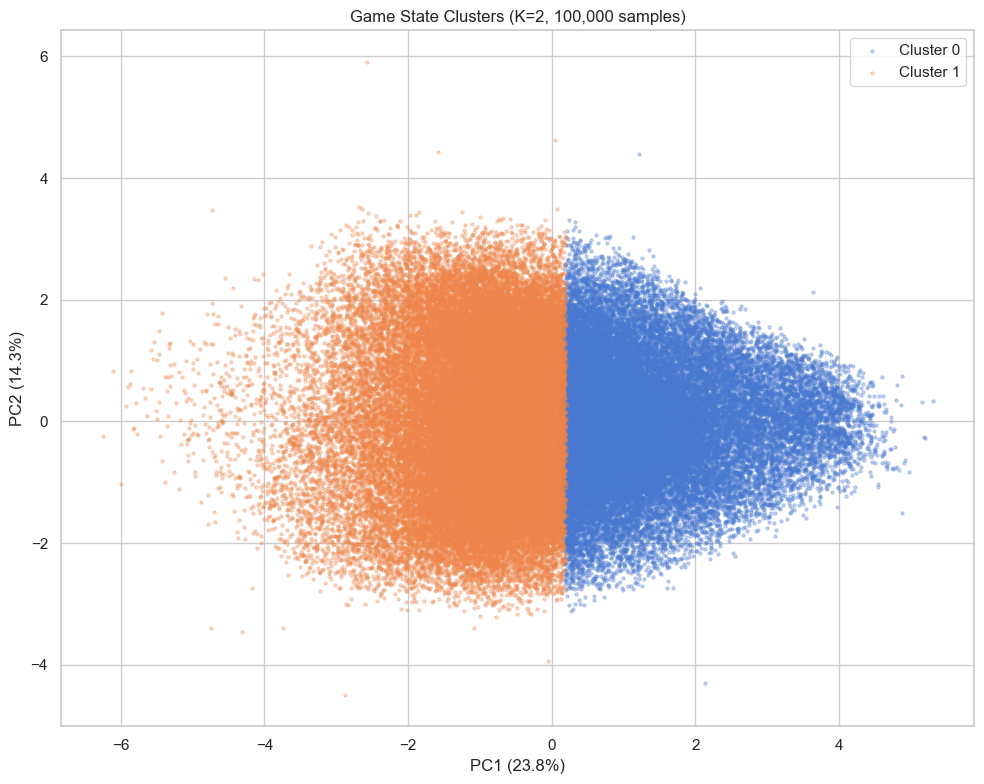


Cluster profiles (means):
           distance  opponent_velocity  opponent_lateral_velocity  opponent_heading_delta  opponent_dist_to_wall_min  our_lateral_velocity  our_dist_to_wall_min  energy_ratio  distance_norm
cluster                                                                                                                                                                                      
0        549.299988              -0.06                       0.01                     0.0                  91.739998                  0.02             67.050003          0.47           0.55
1        393.149994               0.08                      -0.04                     0.0                 121.169998                  0.05            110.419998          0.52           0.39


In [9]:
# PCA visualization with best K
best_k = max(zip(ks, sil_scores), key=lambda x: x[1])[0]
print(f'Best K by silhouette: {best_k}')

km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X_clust)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clust)

fig, ax = plt.subplots(figsize=(10, 8))
for c in range(best_k):
    mask = cluster_labels == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f'Cluster {c}', alpha=0.3, s=5)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title(f'Game State Clusters (K={best_k}, {len(X_clust):,} samples)')
ax.legend()
plt.tight_layout()
plt.show()

# Cluster profiles
sample_with_labels = sample.copy()
sample_with_labels['cluster'] = cluster_labels
print('\nCluster profiles (means):')
print(sample_with_labels.groupby('cluster')[cluster_cols].mean().round(2).to_string())

## 4. Winning Game States (Question 11)

For each cluster, what's the average energy_ratio (proxy for who's winning)?
Are some game states associated with better outcomes for certain bot types?

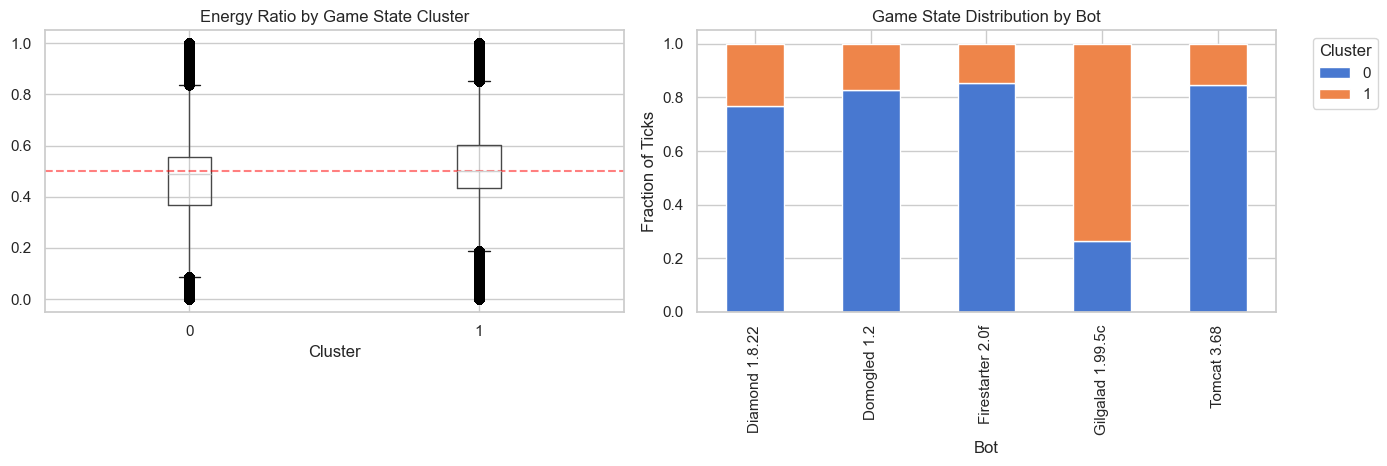

In [10]:
# Add cluster labels to the full sampled ticks
ticks_for_cluster = ticks[cluster_cols].dropna()
if len(ticks_for_cluster) > 0:
    X_all = StandardScaler().fit_transform(ticks_for_cluster.values)
    # Use the same KMeans model (need to refit on full feature scale)
    scaler = StandardScaler().fit(ticks[cluster_cols].dropna().values)
    X_all_scaled = scaler.transform(ticks_for_cluster.values)
    ticks_clustered = ticks.loc[ticks_for_cluster.index].copy()
    ticks_clustered['cluster'] = km_final.predict(X_all_scaled)
    
    # Energy ratio by cluster and bot type
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Overall energy ratio per cluster
    ticks_clustered.boxplot(column='energy_ratio', by='cluster', ax=axes[0])
    axes[0].set_title('Energy Ratio by Game State Cluster')
    axes[0].axhline(y=0.5, color='red', linestyle='--', alpha=0.5)
    axes[0].set_xlabel('Cluster')
    
    # Cluster distribution per top bot (as observer)
    top5 = ticks_clustered['observer_bot'].value_counts().head(5).index
    cluster_dist = ticks_clustered[ticks_clustered['observer_bot'].isin(top5)].groupby(
        ['observer_bot', 'cluster']).size().unstack(fill_value=0)
    cluster_dist_norm = cluster_dist.div(cluster_dist.sum(axis=1), axis=0)
    cluster_dist_norm.plot(kind='bar', stacked=True, ax=axes[1])
    axes[1].set_title('Game State Distribution by Bot')
    axes[1].set_xlabel('Bot')
    axes[1].set_ylabel('Fraction of Ticks')
    axes[1].legend(title='Cluster', bbox_to_anchor=(1.05, 1))
    
    plt.suptitle('')
    plt.tight_layout()
    plt.show()

## 5. Round Outcome Prediction (Question 6)

With ~25K+ rounds (vs. 100 in the initial analysis), we can build a much better
round-outcome model. Features: aggregated tick-level stats per round.

In [11]:
# Build per-round features from tick data
round_features = ticks.groupby(['battle_id', 'round', 'observer_bot']).agg(
    distance_mean=('distance', 'mean'),
    distance_std=('distance', 'std'),
    energy_ratio_mean=('energy_ratio', 'mean'),
    opp_lat_vel_std=('opponent_lateral_velocity', 'std'),
    opp_vel_abs_mean=('opponent_velocity', lambda x: x.abs().mean()),
    our_lat_vel_std=('our_lateral_velocity', 'std'),
    opp_fired_count=('opponent_fired', 'sum'),
    opp_heading_delta_std=('opponent_heading_delta', 'std'),
    wall_dist_mean=('opponent_dist_to_wall_min', 'mean'),
    n_ticks=('distance', 'count'),
).reset_index()

# Merge with scores to get round outcome.
# scores schema (current): battle_id, round, bot (added per-row from dirname),
# net_damage, win_rate, our_hit_rate, opponent_hit_rate, ... (no `total_score`).
# Robocode reports `win_rate` per round directly: 1.0 for the surviving robot,
# 0.0 for the killed one (0.5 in the rare draw). We use it as the win label.
round_data = round_features.merge(
    scores[['battle_id', 'round', 'bot', 'net_damage', 'win_rate']],
    left_on=['battle_id', 'round', 'observer_bot'],
    right_on=['battle_id', 'round', 'bot'],
    how='inner'
)

round_data['won'] = (round_data['win_rate'] >= 0.5).astype(int)

print(f'Round-level samples: {len(round_data):,}')
print(f'Win rate: {round_data["won"].mean():.3f}')


Round-level samples: 5,180
Win rate: 0.506


In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

round_feature_cols = ['distance_mean', 'distance_std', 'energy_ratio_mean',
                      'opp_lat_vel_std', 'opp_vel_abs_mean', 'our_lat_vel_std',
                      'opp_fired_count', 'opp_heading_delta_std', 'wall_dist_mean', 'n_ticks']

X = round_data[round_feature_cols].fillna(0).values
y = round_data['won'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_round = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_round.fit(X_train, y_train)

train_acc = accuracy_score(y_train, rf_round.predict(X_train))
test_acc = accuracy_score(y_test, rf_round.predict(X_test))

print(f'Round Outcome Prediction ({len(y_test):,} test rounds):')
print(f'  Majority baseline: {max(y.mean(), 1-y.mean()):.3f}')
print(f'  Train accuracy:    {train_acc:.3f}')
print(f'  Test accuracy:     {test_acc:.3f}')

# Feature importance
importances = pd.Series(rf_round.feature_importances_, index=round_feature_cols)
print(f'\nFeature importance for round outcome:')
for feat, imp in importances.sort_values(ascending=False).items():
    print(f'  {feat}: {imp:.4f}')

Round Outcome Prediction (1,036 test rounds):


  Majority baseline: 0.506
  Train accuracy:    0.847
  Test accuracy:     0.706

Feature importance for round outcome:
  energy_ratio_mean: 0.3589
  wall_dist_mean: 0.0976
  our_lat_vel_std: 0.0876
  distance_mean: 0.0780
  opp_heading_delta_std: 0.0764
  opp_lat_vel_std: 0.0697
  opp_vel_abs_mean: 0.0673
  n_ticks: 0.0628
  distance_std: 0.0623
  opp_fired_count: 0.0394


## 6. Summary

**Fire Power Prediction:**
- (filled in after running)

**Game State Clusters:**
- (filled in after running)

**Round Outcomes:**
- (filled in after running)

**Win Rankings:**
- (filled in after running)